In [2]:

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_mem(dir, desc):
    with open(f'./{dir}/gpu_usage_log.json', 'r') as file:
        gpu = json.load(file)

    with open(f'./{dir}/ram_usage_log.json', 'r') as file:
        ram = json.load(file)

    with open(f'./{dir}/training_results_detailed_test.json', 'r') as file:
        results= json.load(file)
        baseline_ram= results['baseline_ram_gb']
        baseline_gpu= results['baseline_gpu_gb']


    chunk_size = 10
    gpu=np.array(gpu)-baseline_gpu
    ram=np.array(ram)-baseline_ram
    

    gpu_usage = [
        gpu[i]
        for i in range(0, len(gpu), chunk_size)
    ]

    ram_usage = [
        ram[i]
        for i in range(0, len(ram), chunk_size)
    ]


    time_stamps = [x for x in range(len(gpu_usage))]  # Using index as timestamp if actual timestamps are not available
    # time_deltas = (time_stamps - time_stamps[0]).total_seconds() / 60  # Convert to minutes
    # Plot GPU and RAM usage over time
    plt.figure(figsize=(12, 6))
    plt.plot(time_stamps, gpu_usage, label='GPU Usage ', color='blue')
    plt.plot(time_stamps, ram_usage, label='RAM Usage', color='orange')
    plt.xlabel('Time (s)')
    plt.ylabel('Usage')
    plt.title(f'GPU and RAM Usage Over Time ({desc})')
    plt.legend()
    plt.grid(True)
    plt.show()
    
def plot_loss(dir,desc):
    with open(f'./{dir}/log.json', 'r') as file:
        log = json.load(file)
        
    loss=[x['loss'] for x in log[:-2]]
    step=[x['step'] for x in log[:-2]]
    
    plt.plot(step,loss)
    plt.xlabel('Number of Steps')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.title(f'Loss vs Number of Steps ({desc})')

def plot_conf_matrix(dir, desc):
    with open(f'./{dir}/prediction_answers.json', 'r') as file:
        res = json.load(file)
    
    preds = res['predictions']
    true = res['labels']

    cm = confusion_matrix(true, preds)
    labels = ['World', 'Sports', 'Business', 'Sci/Tech']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    # Plot the confusion matrix
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix ({desc})")
    plt.show()

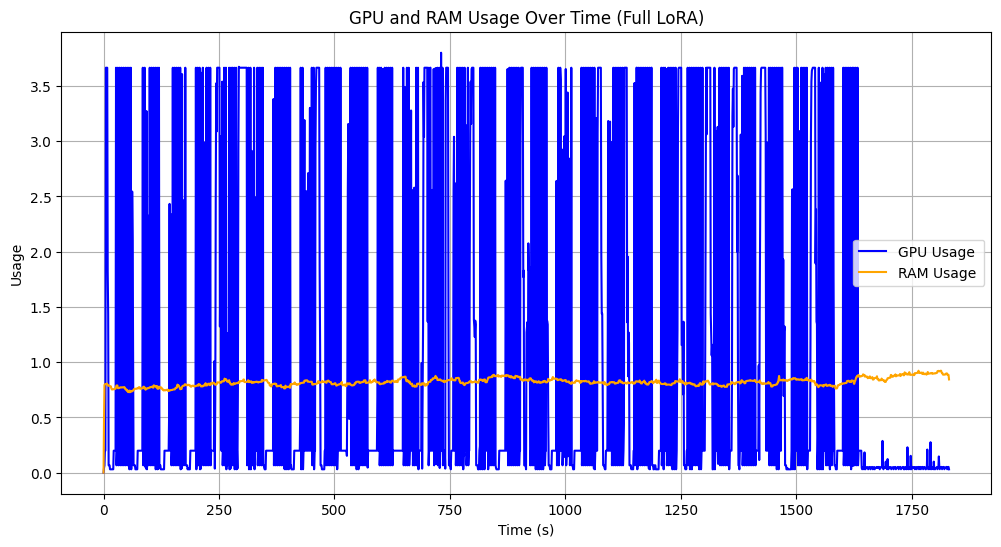

In [3]:
plot_mem('results_Full_20260331_144413',"Full LoRA")

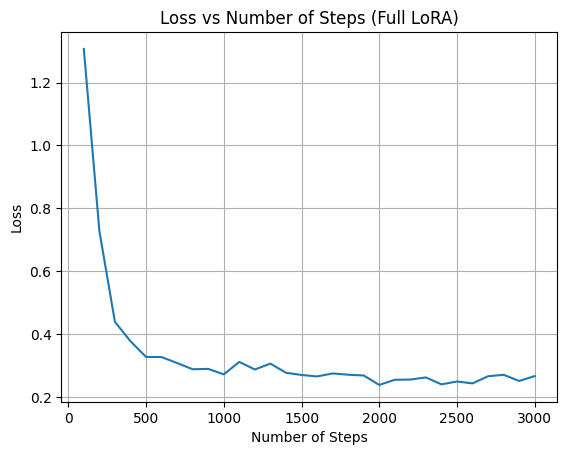

In [4]:
plot_loss('results_Full_20260331_144413',"Full LoRA")

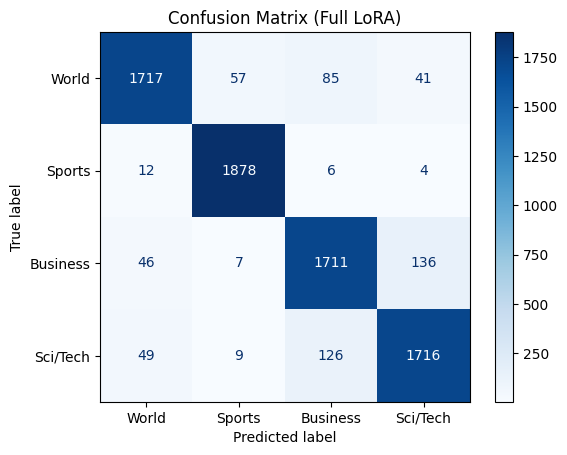

In [5]:
plot_conf_matrix('results_Full_20260331_144413',"Full LoRA")